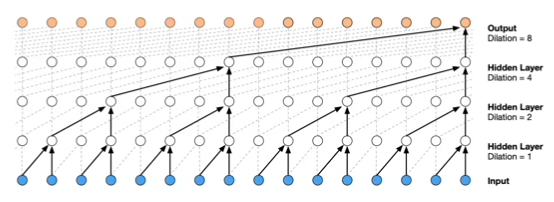

In [6]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [7]:
words = open('../words.txt', 'r').read().splitlines()
words[:8]

['abakus',
 'abandon',
 'abazja',
 'abażur',
 'abażurek',
 'abdukcja',
 'abduktor',
 'abdykacja']

In [8]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)

In [9]:
block_size = 8  # context size

def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size

        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]  # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

In [10]:
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

X_train, Y_train = build_dataset(words[:n1])
X_val, Y_val = build_dataset(words[n1:n2])
X_test, Y_test = build_dataset(words[n2:])

torch.Size([400292, 8]) torch.Size([400292])
torch.Size([50134, 8]) torch.Size([50134])
torch.Size([50015, 8]) torch.Size([50015])


In [11]:
for x, y in zip(X_train[:20], Y_train[:20]):
    print(''.join(itos[ix.item()] for ix in x), '--->', itos[y.item()])

........ ---> e
.......e ---> n
......en ---> d
.....end ---> o
....endo ---> p
...endop ---> r
..endopr ---> o
.endopro ---> t
endoprot ---> e
ndoprote ---> z
doprotez ---> a
oproteza ---> .
........ ---> n
.......n ---> i
......ni ---> e
.....nie ---> k
....niek ---> t
...niekt ---> ó
..niektó ---> r
.niektór ---> y


In [18]:
class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        # out variation = in variation
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    

class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True)     # batch mean
            xvar = x.var(0, keepdim=True, unbiased=True)    # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var

        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]


class Tanh:

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []
    

class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out
    
    def parameters(self):
        return [self.weight]
    

class Flatten:
    def __call__(self, x):
        self.out = x.view(x.shape[0], -1)
        return self.out
    
    def parameters(self):
        return []
    

class Sequential:
    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [19]:
torch.manual_seed(42)

### without scaling

In [22]:
n_emb = 10
n_hidden = 200
model = Sequential([
    Embedding(vocab_size, n_emb),
    Flatten(),
    Linear(n_emb * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

with torch.no_grad():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))    # number of parameters in total

for p in parameters:
    p.requires_grad = True

23574


In [23]:
max_steps = 300000
batch_size = 32
lossi = []

for i in range(max_steps):
    # construct minibatch
    ix = torch.randint(0, X_train.shape[0], (batch_size,))
    Xb, Yb = X_train[ix], Y_train[ix]

    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 300000: 3.5180
  10000/ 300000: 1.9506
  20000/ 300000: 2.0664
  30000/ 300000: 2.1589
  40000/ 300000: 1.9473
  50000/ 300000: 2.3267
  60000/ 300000: 2.0806
  70000/ 300000: 1.8778
  80000/ 300000: 2.0744
  90000/ 300000: 1.9133
 100000/ 300000: 1.6386
 110000/ 300000: 2.0308
 120000/ 300000: 2.0837
 130000/ 300000: 1.9964
 140000/ 300000: 1.8958
 150000/ 300000: 2.0995
 160000/ 300000: 1.7934
 170000/ 300000: 2.1428
 180000/ 300000: 1.6928
 190000/ 300000: 1.5467
 200000/ 300000: 2.0974
 210000/ 300000: 2.0168
 220000/ 300000: 1.8373
 230000/ 300000: 1.8616
 240000/ 300000: 1.8012
 250000/ 300000: 1.8687
 260000/ 300000: 1.5308
 270000/ 300000: 1.6280
 280000/ 300000: 2.2256
 290000/ 300000: 1.8940


In [24]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (X_train, Y_train),
        'val': (X_val, Y_val),
        'test': (X_test, Y_test),
    }[split]

    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.7973593473434448
val 1.8420034646987915


### with scaling

In [25]:
n_emb = 10
n_hidden = 200
model = Sequential([
    Embedding(vocab_size, n_emb),
    Flatten(),
    Linear(n_emb * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

with torch.no_grad():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))    # number of parameters in total

for p in parameters:
    p.requires_grad = True

23574


In [26]:
ix = torch.randint(0, X_train.shape[0], (4,))
Xb, Yb = X_train[ix], Y_train[ix]
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[ 0,  0,  0,  0,  0,  0, 13,  1],
        [ 0,  0,  0,  0,  0,  0, 17, 15],
        [ 0,  0,  0,  0,  0,  0,  0, 13],
        [ 0,  0,  0,  0,  0,  0,  0, 17]])

In [27]:
model.layers[0].out.shape

torch.Size([4, 8, 10])

In [28]:
model.layers[1].out.shape

torch.Size([4, 80])

In [29]:
model.layers[2].out.shape

torch.Size([4, 200])

In [30]:
(torch.randn(4, 80) @ torch.randn(80, 200) + torch.randn(200)).shape

torch.Size([4, 200])

now we want 2\*10=20, not 8\*10=80

In [ ]:
# (1 2) (3 4) (5 6) (7 8)

In [31]:
(torch.randn(4, 4, 80) @ torch.randn(80, 200) + torch.randn(200)).shape
# (4 examples in a batch) x (8/2) x (2*10)

torch.Size([4, 4, 200])

In [35]:
e = torch.randn(4, 8, 10)       # goal: (4, 4, 20)      shape of model.layers[0].out.shape
e.view(4, 4, 20).shape

torch.Size([4, 4, 20])

In [53]:
class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        # out variation = in variation
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    

class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True)     # batch mean
            xvar = x.var(0, keepdim=True, unbiased=True)    # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var

        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]


class Tanh:

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []
    

class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out
    
    def parameters(self):
        return [self.weight]
    

class FlattenConsecutive:
    def __init__(self, n):
        self.n = n

    def __call__(self, x):
        B, T, C = x.shape       # (batch_size, block_size, emb_size)
        x = x.view(B, T//self.n, C*self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x
        return self.out
    
    def parameters(self):
        return []
    

class Sequential:
    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

### 8 entries, so nothing changes

In [54]:
n_emb = 10
n_hidden = 200
model = Sequential([
    Embedding(vocab_size, n_emb),
    FlattenConsecutive(block_size),
    Linear(n_emb * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

with torch.no_grad():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))    # number of parameters in total

for p in parameters:
    p.requires_grad = True

23574


In [55]:
ix = torch.randint(0, X_train.shape[0], (4,))
Xb, Yb = X_train[ix], Y_train[ix]
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[ 0,  0,  0,  0, 11,  1, 17, 19],
        [ 0,  0,  0,  0,  0,  0,  0, 11],
        [ 4,  5,  6,  9,  3, 23, 19, 15],
        [ 0,  0,  0, 16, 15,  3,  8, 12]])

In [56]:
for layer in model.layers:
    print(layer.__class__.__name__,":", tuple(layer.out.shape))

Embedding : (4, 8, 10)
FlattenConsecutive : (4, 80)
Linear : (4, 200)
BatchNorm1d : (4, 200)
Tanh : (4, 200)
Linear : (4, 34)


### 2 entries, like in wavenet

In [57]:
n_emb = 10
n_hidden = 68       # so that the number of parameters is the same as before
model = Sequential([
    Embedding(vocab_size, n_emb),
    FlattenConsecutive(2), Linear(n_emb * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

with torch.no_grad():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))    # number of parameters in total

for p in parameters:
    p.requires_grad = True

22950


In [58]:
ix = torch.randint(0, X_train.shape[0], (4,))
Xb, Yb = X_train[ix], Y_train[ix]
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[ 0,  0, 13,  1, 17,  9,  1, 18],
        [ 0,  0,  0,  0, 13, 20, 12,  5],
        [24,  5,  9, 14,  1,  3, 24,  5],
        [ 4,  1, 14, 19,  5, 17,  9,  1]])

In [59]:
for layer in model.layers:
    print(layer.__class__.__name__,":", tuple(layer.out.shape))

Embedding : (4, 8, 10)
FlattenConsecutive : (4, 4, 20)
Linear : (4, 4, 68)
BatchNorm1d : (4, 4, 68)
Tanh : (4, 4, 68)
FlattenConsecutive : (4, 2, 136)
Linear : (4, 2, 68)
BatchNorm1d : (4, 2, 68)
Tanh : (4, 2, 68)
FlattenConsecutive : (4, 136)
Linear : (4, 68)
BatchNorm1d : (4, 68)
Tanh : (4, 68)
Linear : (4, 34)


In [60]:
model.layers[3].running_mean.shape

torch.Size([1, 4, 68])

In [48]:
max_steps = 300000
batch_size = 32
lossi = []

for i in range(max_steps):
    # construct minibatch
    ix = torch.randint(0, X_train.shape[0], (batch_size,))
    Xb, Yb = X_train[ix], Y_train[ix]

    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 300000: 3.5124
  10000/ 300000: 2.1687
  20000/ 300000: 2.4051
  30000/ 300000: 1.6013
  40000/ 300000: 2.4214
  50000/ 300000: 2.0237
  60000/ 300000: 2.0510
  70000/ 300000: 2.1489
  80000/ 300000: 1.8330
  90000/ 300000: 1.8420
 100000/ 300000: 2.2368
 110000/ 300000: 1.9817
 120000/ 300000: 1.9507
 130000/ 300000: 1.8506
 140000/ 300000: 1.7317
 150000/ 300000: 2.3328
 160000/ 300000: 1.5892
 170000/ 300000: 1.8437
 180000/ 300000: 1.4860
 190000/ 300000: 2.0593
 200000/ 300000: 1.5428
 210000/ 300000: 1.6593
 220000/ 300000: 1.8852
 230000/ 300000: 1.9251
 240000/ 300000: 1.9151
 250000/ 300000: 1.5998
 260000/ 300000: 1.6415
 270000/ 300000: 1.9807
 280000/ 300000: 1.5575
 290000/ 300000: 2.2888


In [49]:
split_loss('train')
split_loss('val')

train 1.7940280437469482
val 1.827275037765503


### bug fix
in BachNorm1d \__call__ x should be 2d, but it is 3d now

3d because we want to also normalize by positions tgo prevent the model from learning simple statistics over positions

In [74]:
class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        # out variation = in variation
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    

class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # forward pass
        if self.training:
            if x.ndim == 2:
                dim = 0
            elif x.ndim == 3:
                dim = (0, 1)
            xmean = x.mean(dim, keepdim=True)     # batch mean
            xvar = x.var(dim, keepdim=True)    # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var

        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]


class Tanh:

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []
    

class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out
    
    def parameters(self):
        return [self.weight]
    

class FlattenConsecutive:
    def __init__(self, n):
        self.n = n

    def __call__(self, x):
        B, T, C = x.shape       # (batch_size, block_size, emb_size)
        x = x.view(B, T//self.n, C*self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x
        return self.out
    
    def parameters(self):
        return []
    

class Sequential:
    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [75]:
n_emb = 10
n_hidden = 68       # so that the number of parameters is the same as before
model = Sequential([
    Embedding(vocab_size, n_emb),
    FlattenConsecutive(2), Linear(n_emb * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

with torch.no_grad():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))    # number of parameters in total

for p in parameters:
    p.requires_grad = True

22950


In [76]:
max_steps = 300000
batch_size = 32
lossi = []

for i in range(max_steps):
    # construct minibatch
    ix = torch.randint(0, X_train.shape[0], (batch_size,))
    Xb, Yb = X_train[ix], Y_train[ix]

    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    break

      0/ 300000: 3.5288


In [77]:
for layer in model.layers:
    print(layer.__class__.__name__,":", tuple(layer.out.shape))

Embedding : (32, 8, 10)
FlattenConsecutive : (32, 4, 20)
Linear : (32, 4, 68)
BatchNorm1d : (32, 4, 68)
Tanh : (32, 4, 68)
FlattenConsecutive : (32, 2, 136)
Linear : (32, 2, 68)
BatchNorm1d : (32, 2, 68)
Tanh : (32, 2, 68)
FlattenConsecutive : (32, 136)
Linear : (32, 68)
BatchNorm1d : (32, 68)
Tanh : (32, 68)
Linear : (32, 34)


In [78]:
model.layers[3].running_mean.shape

torch.Size([1, 1, 68])

In [79]:
max_steps = 300000
batch_size = 32
lossi = []

for i in range(max_steps):
    # construct minibatch
    ix = torch.randint(0, X_train.shape[0], (batch_size,))
    Xb, Yb = X_train[ix], Y_train[ix]

    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 300000: 3.5238
  10000/ 300000: 1.7740
  20000/ 300000: 1.8263
  30000/ 300000: 2.3094
  40000/ 300000: 1.7221
  50000/ 300000: 1.8007
  60000/ 300000: 1.6803
  70000/ 300000: 2.2577
  80000/ 300000: 1.8399
  90000/ 300000: 1.9939
 100000/ 300000: 2.0245
 110000/ 300000: 1.6117
 120000/ 300000: 2.0817
 130000/ 300000: 2.0414
 140000/ 300000: 2.1435
 150000/ 300000: 1.6847
 160000/ 300000: 1.7717
 170000/ 300000: 1.4650
 180000/ 300000: 1.7700
 190000/ 300000: 1.6412
 200000/ 300000: 1.7908
 210000/ 300000: 1.8541
 220000/ 300000: 2.3774
 230000/ 300000: 2.2130
 240000/ 300000: 1.8025
 250000/ 300000: 1.8607
 260000/ 300000: 1.5594
 270000/ 300000: 2.0429
 280000/ 300000: 1.3044
 290000/ 300000: 1.7542


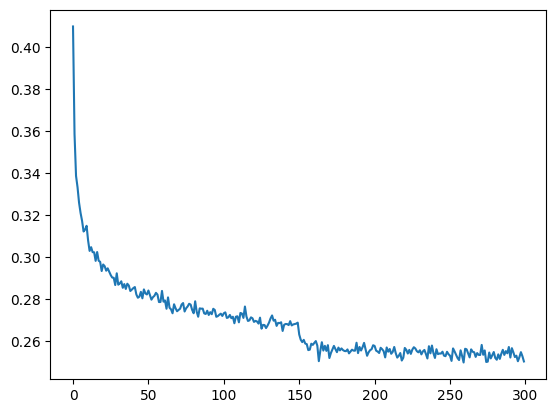

In [80]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [81]:
for layer in model.layers:
    layer.training = False

In [82]:
split_loss('train')
split_loss('val')

train 1.7691911458969116
val 1.814589262008667
